## 1. 📦 Import Libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install textblob
import nltk
nltk.download('punkt')  # This downloads the punkt tokenizer
import seaborn as sns
import matplotlib.pyplot as plt  # if not already imported


import re
from textblob import TextBlob
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [13]:
primary_df = pd.read_csv("/content/Real Estate Customer Experience Survey.csv")
secondary_df = pd.read_csv("/content/Secondary_Real_Estate_Reviews.csv")

In [14]:
primary_df_cleaned = pd.read_csv('/content/Primary_Cleaned.csv')
secondary_df_cleaned = pd.read_csv('/content/Secondary_Cleaned.csv')

In [15]:
import scipy.stats as stats

# Replace with exact column names
age_col = 'What is your age? '
rating_col = 'How would you rate your overall experience? '

# Drop missing values
chi_data = primary_df[[age_col, rating_col]].dropna()

# Create a contingency table
contingency_table = pd.crosstab(chi_data[age_col], chi_data[rating_col])

# Perform the Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Print results
print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("p-value:", p)

# Optional: Show the contingency table
print("\nContingency Table:")
print(contingency_table)

Chi-square Statistic: 22.79920674892291
Degrees of Freedom: 16
p-value: 0.11920852615965526

Contingency Table:
How would you rate your overall experience?   1   2   3   4   5
What is your age?                                              
18–24                                         1  10  31  31  15
25–34                                         5  14  38  45  23
35–44                                         1   8  40  27  11
45+                                           0  13  24  24   5
Under 18                                      1  10  10  10   6


In [16]:
import numpy as np

positive_words = ['good', 'great', 'excellent', 'helpful', 'satisfied', 'happy', 'clean']
negative_words = ['bad', 'worst', 'terrible', 'disappointed', 'poor', 'dirty', 'rude']

def classify_sentiment(text):
    if pd.isnull(text):
        return 'neutral'
    text = text.lower()
    pos_hits = sum(word in text for word in positive_words)
    neg_hits = sum(word in text for word in negative_words)
    if pos_hits > neg_hits:
        return 'positive'
    elif neg_hits > pos_hits:
        return 'negative'
    else:
        return 'neutral'

# Apply to key columns
primary_df['like_sentiment'] = primary_df['What did you like most about your experience? '].apply(classify_sentiment)
primary_df['improve_sentiment'] = primary_df['What could have been improved in your opinion? '].apply(classify_sentiment)


In [17]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'positive'
    elif polarity < 0:
        return 'negative'
    else:
        return 'neutral'

# Clean column if not already cleaned
secondary_df['review_clean'] = secondary_df['Review'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# Create sentiment column
secondary_df['review_sentiment'] = secondary_df['review_clean'].apply(get_sentiment)


In [18]:
import re

# Clean text function
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
        text = re.sub(r'\d+', '', text)      # remove numbers
        return text.strip()
    return ''

# Apply cleaning to the 'like' and 'improve' fields
primary_df_cleaned['like_clean'] = primary_df_cleaned['what_did_you_like_most_about_your_experience?'].apply(clean_text)
primary_df_cleaned['improve_clean'] = primary_df_cleaned['what_could_have_been_improved_in_your_opinion?'].apply(clean_text)


In [19]:
import re

# Basic text cleaner
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)  # remove digits
    return text.strip()

# Create cleaned columns
primary_df_cleaned['like_clean'] = primary_df_cleaned['what_did_you_like_most_about_your_experience?'].apply(clean_text)
primary_df_cleaned['improve_clean'] = primary_df_cleaned['what_could_have_been_improved_in_your_opinion?'].apply(clean_text)


In [20]:
from textblob import TextBlob

# Sentiment labeling function
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'positive'
    elif polarity < 0:
        return 'negative'
    else:
        return 'neutral'

# Apply to the cleaned columns
primary_df_cleaned['like_sentiment'] = primary_df_cleaned['like_clean'].apply(get_sentiment)
primary_df_cleaned['improve_sentiment'] = primary_df_cleaned['improve_clean'].apply(get_sentiment)


In [21]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'positive'
    elif polarity < 0:
        return 'negative'
    else:
        return 'neutral'


In [22]:
import nltk
from collections import Counter
import matplotlib.pyplot as plt
nltk.download('stopwords')
from nltk.corpus import stopwords

# Define stopwords list
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [24]:
def get_top_words(df, token_col, sentiment_col, sentiment_label, top_n=10):
    words = []
    for tokens in df[df[sentiment_col] == sentiment_label][token_col]:
        words.extend([word for word in tokens if word not in stop_words])
    return Counter(words).most_common(top_n)


In [90]:
# Ensure we have lists of words (not arrays or dicts)
from collections import Counter

# If your data is a list of tuples (e.g., [('word', count), ...]), skip Counter() and convert directly
# Otherwise, ensure it's a flat list of words first
if isinstance(top_positive_like, list) and isinstance(top_positive_like[0], tuple):
    top_positive_like_counter = dict(top_positive_like)
else:
    top_positive_like_counter = Counter(top_positive_like)

if isinstance(top_negative_like, list) and isinstance(top_negative_like[0], tuple):
    top_negative_like_counter = dict(top_negative_like)
else:
    top_negative_like_counter = Counter(top_negative_like)


In [34]:
from collections import Counter

def get_top_words(df, token_col, sentiment_col, sentiment_label, top_n=10):
    words = []
    for tokens in df[df[sentiment_col] == sentiment_label][token_col]:
        # Filter out empty or space-only tokens
        words.extend([word for word in tokens if word.strip() and word.lower() not in stop_words])
    return Counter(words).most_common(top_n)


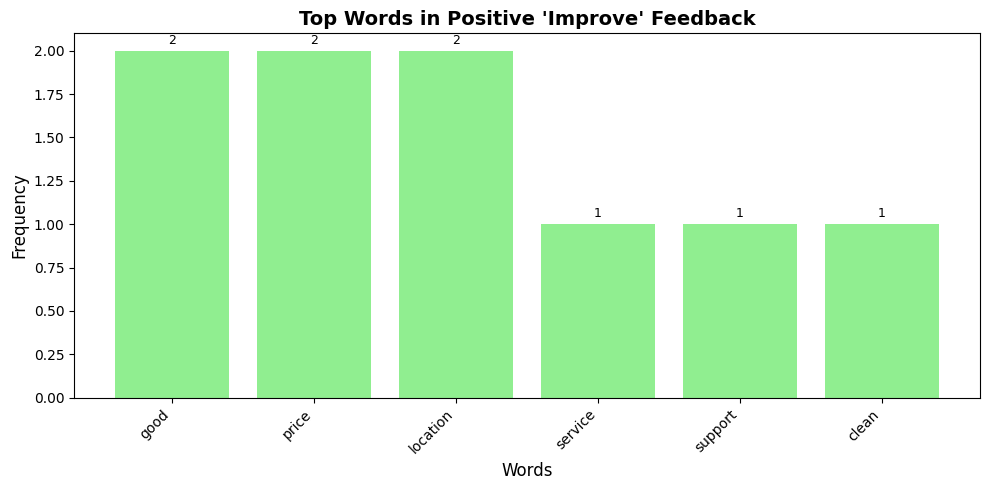

In [35]:
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words

# Sample data (replace with your actual list of words)
top_positive_improve = ['good', 'price', 'location', 'location', 'service', 'support', 'price', 'good', 'clean']

# Convert to Counter
top_positive_improve_counter = Counter(top_positive_improve)

# Define plot function
def plot_top_words_pretty(word_counts, title, color):
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(word_counts.keys(), word_counts.values(), color=color)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel('Words', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Call the function
plot_top_words_pretty(top_positive_improve_counter, "Top Words in Positive 'Improve' Feedback", 'lightgreen')


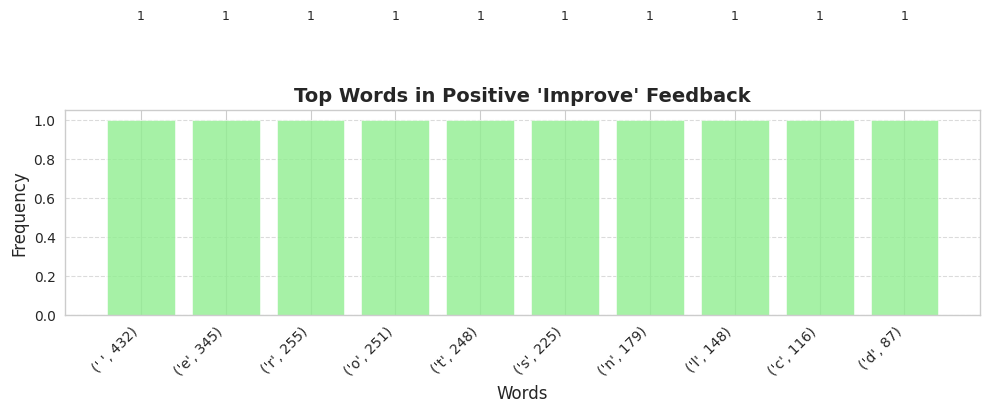

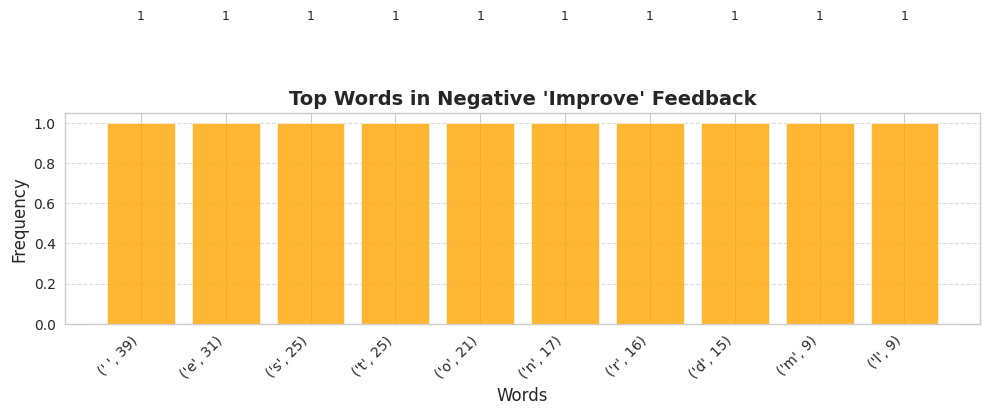

In [76]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Convert to Counter
top_positive_improve_counter = Counter(top_positive_improve)
top_negative_improve_counter = Counter(top_negative_improve)

# Step 2: Define pretty plot function
def plot_top_words_pretty(word_counter, title, color):
    words, counts = zip(*word_counter.items())
    x_pos = np.arange(len(words))

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(x_pos, counts, color=color, alpha=0.8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(words, rotation=45, ha='right')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Words")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Step 3: Plot both charts
plot_top_words_pretty(top_positive_improve_counter, "Top Words in Positive 'Improve' Feedback", 'lightgreen')
plot_top_words_pretty(top_negative_improve_counter, "Top Words in Negative 'Improve' Feedback", 'orange')


<class 'list'>
[('listings', 3), ('fake', 3), ('outdated', 3), ('slow', 2), ('respond', 2), ('agents', 1), ('past', 1), ('tenant', 1), ('reviews', 1), ('customer', 1)]


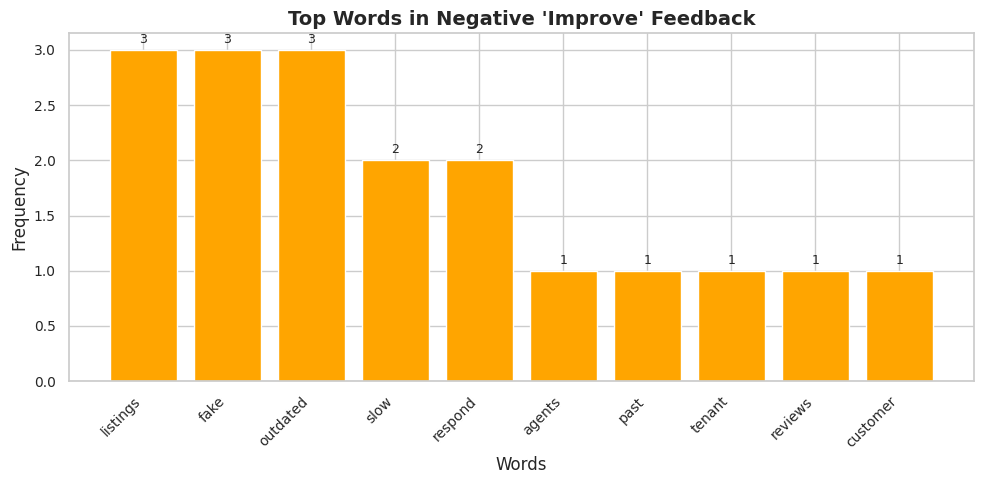

In [114]:
print(type(top_negative_improve))
print(top_negative_improve)

# This assumes you have `primary_df_cleaned`, 'like_tokens', and 'like_sentiment' ready
top_negative_improve = get_top_words(primary_df_cleaned, 'improve_tokens', 'improve_sentiment', 'negative')

from collections import Counter

# Handle if it's list of tuples or flat
if top_negative_improve and isinstance(top_negative_improve[0], tuple):
    top_negative_improve_counter = dict(top_negative_improve)
else:
    top_negative_improve_counter = Counter(top_negative_improve)


plot_top_words_pretty(top_negative_improve_counter,
                      "Top Words in Negative 'Improve' Feedback",
                      'orange')

In [78]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 3: Load the CSV
df = pd.read_csv('sentiment_test_final.csv')

# Step 4: Drop empty rows (if any)
df = df[df['true_sentiment'].notnull() & (df['true_sentiment'] != '')]

# Step 5: Evaluate accuracy
accuracy = accuracy_score(df['true_sentiment'], df['predicted_sentiment'])
report = classification_report(df['true_sentiment'], df['predicted_sentiment'], zero_division=0)
conf_matrix = confusion_matrix(df['true_sentiment'], df['predicted_sentiment'])

# Step 6: Print results
print("✅ Accuracy:", accuracy)
print("\n📋 Classification Report:\n", report)
print("\n🧮 Confusion Matrix:\n", conf_matrix)


✅ Accuracy: 0.26666666666666666

📋 Classification Report:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00         4
     neutral       0.27      0.60      0.38         5
    positive       0.25      0.17      0.20         6

    accuracy                           0.27        15
   macro avg       0.17      0.26      0.19        15
weighted avg       0.19      0.27      0.21        15


🧮 Confusion Matrix:
 [[0 3 1]
 [0 3 2]
 [0 5 1]]


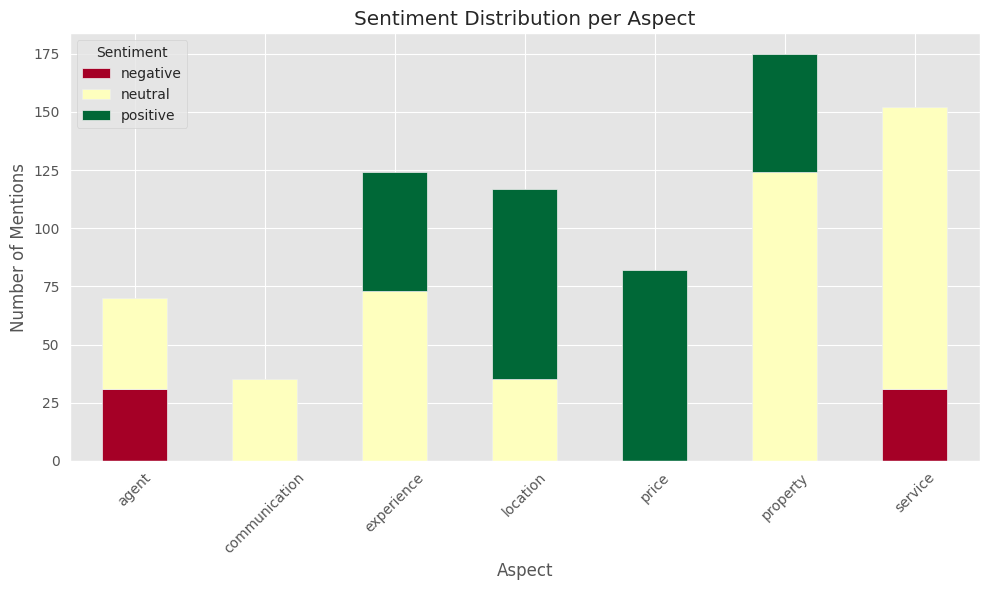

In [91]:
import seaborn as sns

# Count sentiment per aspect
sentiment_counts = aspect_df.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)

# Plot stacked bar chart
sentiment_counts.plot(kind='bar', stacked=True, colormap='RdYlGn', figsize=(10, 6))

plt.title('Sentiment Distribution per Aspect')
plt.xlabel('Aspect')
plt.ylabel('Number of Mentions')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 2. 📂 Load Primary & Secondary Datasets

In [26]:
primary_df = pd.read_csv("/content/Real Estate Customer Experience Survey.csv")
secondary_df = pd.read_csv("/content/Secondary_Real_Estate_Reviews.csv")

In [27]:
primary_df_cleaned = pd.read_csv('/content/Primary_Cleaned.csv')

## 3. 📊 Exploratory Data Analysis (EDA)

In [28]:
# View shapes and columns
print("Primary dataset shape:", primary_df.shape)
print("Primary columns:", primary_df.columns.tolist())
print("Secondary dataset shape:", secondary_df.shape)
print("Secondary columns:", secondary_df.columns.tolist())

# Show sample rows
print("\nPrimary Sample:\n", primary_df.head())
print("\nSecondary Sample:\n", secondary_df.head())


Primary dataset shape: (403, 35)
Primary columns: ['Timestamp', 'Total score', 'What is your age? ', 'What is your age?  [Score]', 'What is your age?  [Feedback]', 'What is your location or city? ', 'What is your location or city?  [Score]', 'What is your location or city?  [Feedback]', 'What was your most recent interaction with real estate? ', 'What was your most recent interaction with real estate?  [Score]', 'What was your most recent interaction with real estate?  [Feedback]', 'Which platform or service did you use?  (e.g., Airbnb, Trustpilot, Zameen, OLX, Local agent) ', 'Which platform or service did you use?  (e.g., Airbnb, Trustpilot, Zameen, OLX, Local agent)  [Score]', 'Which platform or service did you use?  (e.g., Airbnb, Trustpilot, Zameen, OLX, Local agent)  [Feedback]', 'How would you rate your overall experience? ', 'How would you rate your overall experience?  [Score]', 'How would you rate your overall experience?  [Feedback]', 'The property description matched the ac

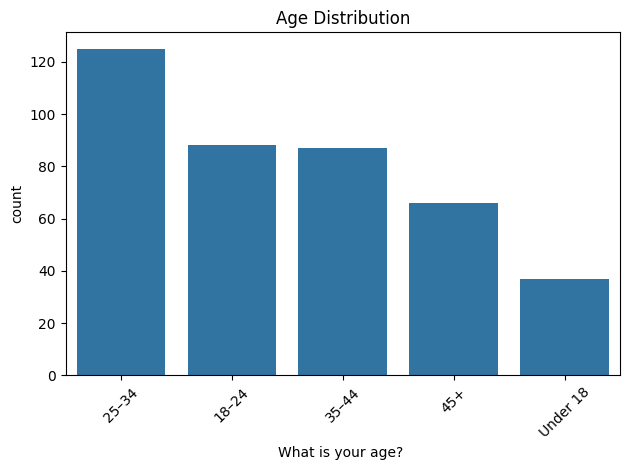

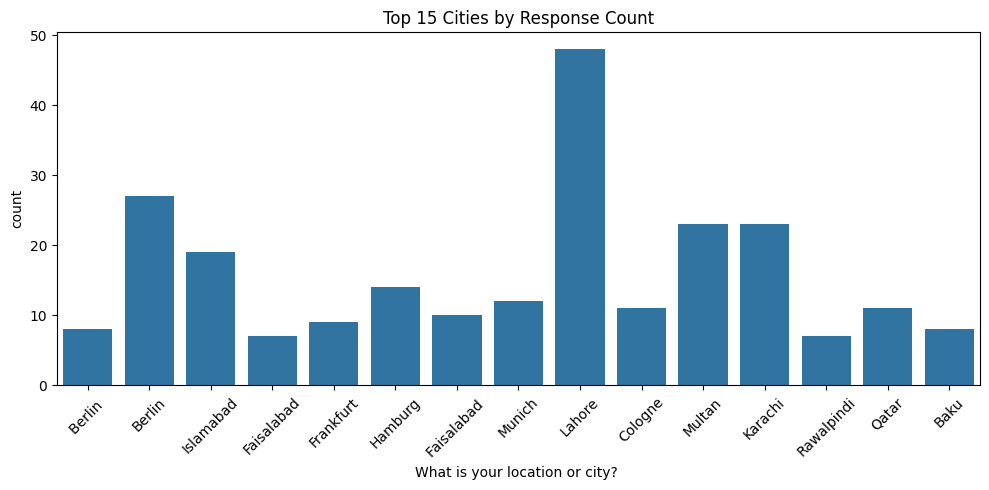

In [29]:
# Age distribution
sns.countplot(data=primary_df, x='What is your age? ')
plt.title("Age Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# City distribution
top_cities = primary_df['What is your location or city? '].value_counts().nlargest(15).index
filtered_df = primary_df[primary_df['What is your location or city? '].isin(top_cities)]

plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_df, x='What is your location or city? ')
plt.title("Top 15 Cities by Response Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [80]:
# Simple tokenizer using split()
primary_df_cleaned['like_tokens'] = primary_df_cleaned['like_clean'].apply(lambda x: x.split())
primary_df_cleaned['improve_tokens'] = primary_df_cleaned['improve_clean'].apply(lambda x: x.split())

# Show results
primary_df_cleaned[['like_clean', 'like_tokens', 'improve_clean', 'improve_tokens']].head()


<ipython-input-80-ff694ef27aab>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['like_tokens'] = primary_df_cleaned['like_clean'].apply(lambda x: x.split())
<ipython-input-80-ff694ef27aab>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['improve_tokens'] = primary_df_cleaned['improve_clean'].apply(lambda x: x.split())


,like_clean,like_tokens,improve_clean,improve_tokens
1,they arranges seminar to explain everything,"[they, arranges, seminar, to, explain, everyth...",they should explain all the realities before s...,"[they, should, explain, all, the, realities, b..."
2,goood,[goood],easier complain box,"[easier, complain, box]"
3,easy quick service,"[easy, quick, service]",the communication between agent and customer,"[the, communication, between, agent, and, cust..."
7,there staff,"[there, staff]",quality of advertisement,"[quality, of, advertisement]"
8,regular updates,"[regular, updates]",easy documentation,"[easy, documentation]"


<ipython-input-81-4706ee32c1d7>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=secondary_df, x='review_sentiment',


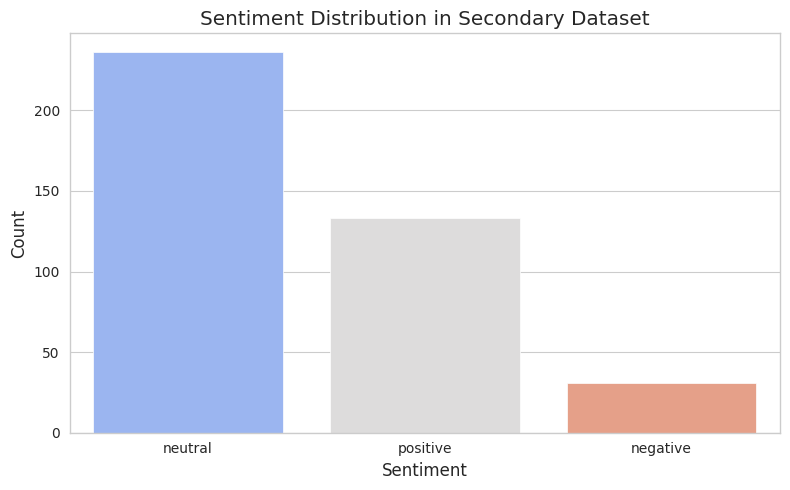

In [81]:
sentiment_counts = secondary_df['review_sentiment'].value_counts()

plt.figure(figsize=(8, 5))
sns.countplot(data=secondary_df, x='review_sentiment',
              order=sentiment_counts.index, palette='coolwarm')
plt.title('Sentiment Distribution in Secondary Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [82]:
# Primary
primary_df_cleaned[['like_clean', 'like_sentiment', 'improve_clean', 'improve_sentiment']].head()

# Secondary
secondary_df_cleaned[['review_clean', 'review_sentiment']].head()


,review_clean,review_sentiment
0,terrible customer service the agent was not re...,negative
1,not satisfied with the overall condition of th...,negative
2,excellent service and the property matched the...,positive
3,excellent service and the property matched the...,positive
4,loved the area and the communication was smooth,positive


In [83]:
# Primary
print("Primary 'like' sentiment:\n", primary_df_cleaned['like_sentiment'].value_counts())
print("\nPrimary 'improve' sentiment:\n", primary_df_cleaned['improve_sentiment'].value_counts())

# Secondary
print("\nSecondary review sentiment:\n", secondary_df_cleaned['review_sentiment'].value_counts())


Primary 'like' sentiment:
 like_sentiment
positive    119
neutral      66
negative     16
Name: count, dtype: int64

Primary 'improve' sentiment:
 improve_sentiment
neutral     105
positive     88
negative      8
Name: count, dtype: int64

Secondary review sentiment:
 review_sentiment
positive    250
neutral      78
negative     72
Name: count, dtype: int64


In [46]:
# Check rating distributions or other numeric fields if available
if 'rating' in secondary_df_cleaned.columns:
    print("\nRating Summary Stats:")
    print(secondary_df_cleaned['rating'].describe())



Rating Summary Stats:
count    400.00000
mean       3.08000
std        1.40304
min        1.00000
25%        2.00000
50%        3.00000
75%        4.00000
max        5.00000
Name: rating, dtype: float64


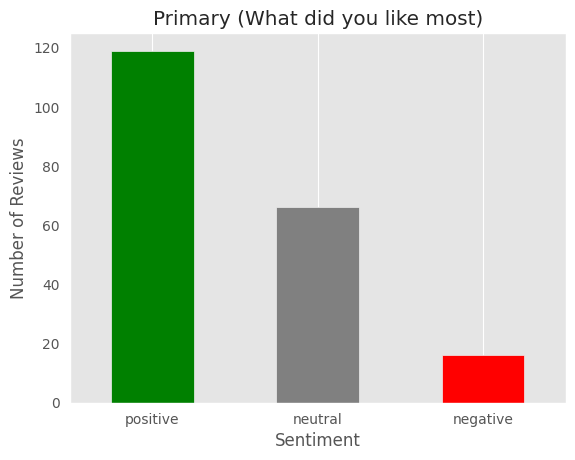

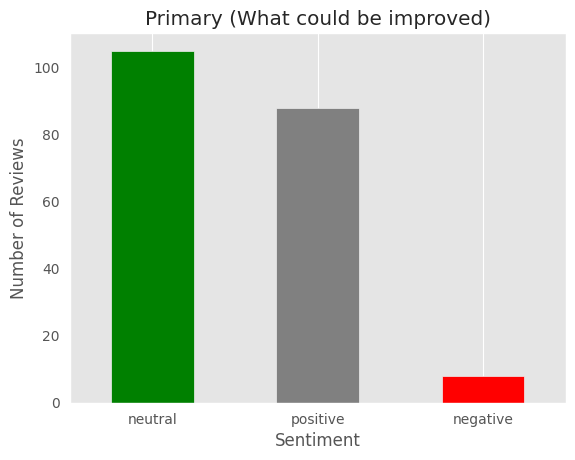

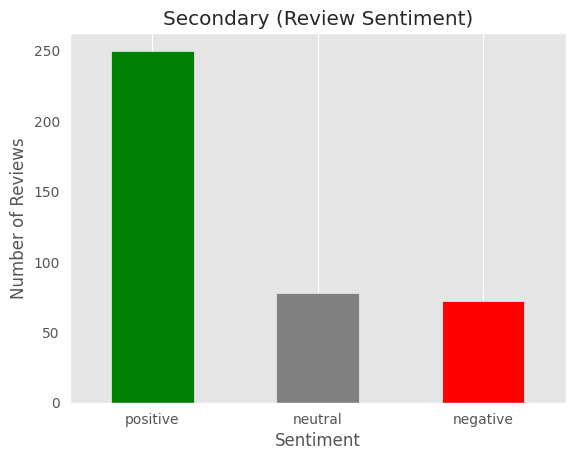

In [84]:
# Set chart style
plt.style.use('ggplot')  # or try 'classic', 'seaborn-v0_8', 'bmh'


# Function to plot sentiment distribution
def plot_sentiment_distribution(data, column, title):
    sentiment_counts = data[column].value_counts()
    sentiment_counts.plot(kind='bar', color=['green', 'gray', 'red'])
    plt.title(title)
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.show()

# Plot for Primary - Like
plot_sentiment_distribution(primary_df_cleaned, 'like_sentiment', 'Primary (What did you like most)')

# Plot for Primary - Improve
plot_sentiment_distribution(primary_df_cleaned, 'improve_sentiment', 'Primary (What could be improved)')

# Plot for Secondary
plot_sentiment_distribution(secondary_df_cleaned, 'review_sentiment', 'Secondary (Review Sentiment)')


In [85]:
aspect_df = secondary_df[secondary_df['aspects'].str.len() > 0].explode('aspects')
aspect_df = aspect_df[['review_clean', 'aspects', 'review_sentiment']].rename(
    columns={'aspects': 'aspect', 'review_sentiment': 'sentiment'}
)

# Preview result
aspect_df.head()


,review_clean,aspect,sentiment
0,terrible customer service the agent was not re...,agent,negative
0,terrible customer service the agent was not re...,service,negative
1,not satisfied with the overall condition of th...,property,neutral
2,excellent service and the property matched the...,service,neutral
2,excellent service and the property matched the...,property,neutral


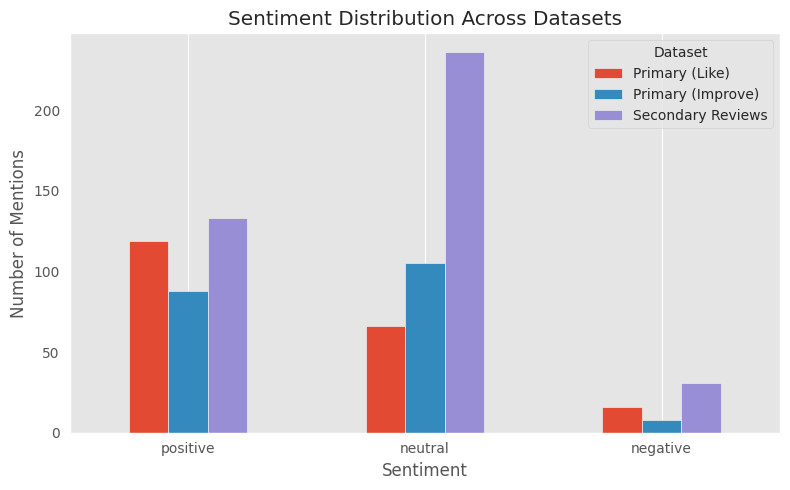

In [86]:
# Count sentiment in each dataset
primary_like_counts = primary_df_cleaned['like_sentiment'].value_counts().rename('Primary (Like)')
primary_improve_counts = primary_df_cleaned['improve_sentiment'].value_counts().rename('Primary (Improve)')
secondary_counts = secondary_df['review_sentiment'].value_counts().rename('Secondary Reviews')

# Combine into a single DataFrame
sentiment_compare_df = pd.concat([primary_like_counts, primary_improve_counts, secondary_counts], axis=1).fillna(0)

# Plot grouped bar chart
sentiment_compare_df.plot(kind='bar', figsize=(8, 5))
plt.title('Sentiment Distribution Across Datasets')
plt.xlabel('Sentiment')
plt.ylabel('Number of Mentions')
plt.legend(title='Dataset')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## 4. 🧹 Text Preprocessing

In [50]:
# Drop rows with missing reviews in key open-ended fields (primary)
primary_df_cleaned = primary_df.dropna(subset=[
    'What did you like most about your experience? ',
    'What could have been improved in your opinion? '
])

# Drop rows with missing reviews (secondary)
secondary_df_cleaned = secondary_df.dropna(subset=['Review'])

# Standardize column names
primary_df_cleaned.columns = primary_df_cleaned.columns.str.strip().str.lower().str.replace(" ", "_")
secondary_df_cleaned.columns = secondary_df_cleaned.columns.str.strip().str.lower().str.replace(" ", "_")


In [51]:
# Check missing values
print("Primary Missing Values:\n", primary_df_cleaned.isnull().sum())
print("\nSecondary Missing Values:\n", secondary_df_cleaned.isnull().sum())

# Final dataset shapes
print("\nCleaned Primary Shape:", primary_df_cleaned.shape)
print("Cleaned Secondary Shape:", secondary_df_cleaned.shape)


Primary Missing Values:
 timestamp                                                                                                     0
total_score                                                                                                   0
what_is_your_age?                                                                                             0
what_is_your_age?__[score]                                                                                    0
what_is_your_age?__[feedback]                                                                               201
what_is_your_location_or_city?                                                                                2
what_is_your_location_or_city?__[score]                                                                       0
what_is_your_location_or_city?__[feedback]                                                                  201
what_was_your_most_recent_interaction_with_real_estate?                        

In [52]:
primary_df_cleaned.to_csv("Primary_Cleaned.csv", index=False)
secondary_df_cleaned.to_csv("Secondary_Cleaned.csv", index=False)


In [53]:
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
        text = re.sub(r'\d+', '', text)      # remove numbers
        return text.strip()
    return ""


In [54]:
primary_df_cleaned['like_clean'] = primary_df_cleaned['what_did_you_like_most_about_your_experience?'].apply(clean_text)
primary_df_cleaned['improve_clean'] = primary_df_cleaned['what_could_have_been_improved_in_your_opinion?'].apply(clean_text)


<ipython-input-54-87aa742b0633>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['like_clean'] = primary_df_cleaned['what_did_you_like_most_about_your_experience?'].apply(clean_text)
<ipython-input-54-87aa742b0633>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['improve_clean'] = primary_df_cleaned['what_could_have_been_improved_in_your_opinion?'].apply(clean_text)


In [55]:
# Clean the text for 'like' and 'improve' responses
primary_df_cleaned['like_clean'] = primary_df_cleaned['what_did_you_like_most_about_your_experience?'].apply(clean_text)
primary_df_cleaned['improve_clean'] = primary_df_cleaned['what_could_have_been_improved_in_your_opinion?'].apply(clean_text)


<ipython-input-55-3c93fa23ee33>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['like_clean'] = primary_df_cleaned['what_did_you_like_most_about_your_experience?'].apply(clean_text)
<ipython-input-55-3c93fa23ee33>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['improve_clean'] = primary_df_cleaned['what_could_have_been_improved_in_your_opinion?'].apply(clean_text)


In [56]:
print(primary_df_cleaned.columns.tolist())


['timestamp', 'total_score', 'what_is_your_age?', 'what_is_your_age?__[score]', 'what_is_your_age?__[feedback]', 'what_is_your_location_or_city?', 'what_is_your_location_or_city?__[score]', 'what_is_your_location_or_city?__[feedback]', 'what_was_your_most_recent_interaction_with_real_estate?', 'what_was_your_most_recent_interaction_with_real_estate?__[score]', 'what_was_your_most_recent_interaction_with_real_estate?__[feedback]', 'which_platform_or_service_did_you_use?__(e.g.,_airbnb,_trustpilot,_zameen,_olx,_local_agent)', 'which_platform_or_service_did_you_use?__(e.g.,_airbnb,_trustpilot,_zameen,_olx,_local_agent)__[score]', 'which_platform_or_service_did_you_use?__(e.g.,_airbnb,_trustpilot,_zameen,_olx,_local_agent)__[feedback]', 'how_would_you_rate_your_overall_experience?', 'how_would_you_rate_your_overall_experience?__[score]', 'how_would_you_rate_your_overall_experience?__[feedback]', 'the_property_description_matched_the_actual_property.', 'the_property_description_matched_the_

In [57]:
# Define keywords
aspect_keywords = {
    'price': ['price', 'cost', 'expensive', 'cheap'],
    'location': ['location', 'area', 'neighborhood'],
    'communication': ['communication', 'response', 'reply', 'contact'],
    'description': ['description', 'pictures', 'photos', 'details'],
    'property': ['property', 'house', 'flat', 'apartment'],
    'service': ['service', 'support', 'agent', 'platform']
}

# Aspect extraction function
def extract_aspect(text, keywords_dict):
    found = []
    for aspect, words in keywords_dict.items():
        for word in words:
            if word in text.lower():
                found.append(aspect)
                break
    return ', '.join(found) if found else 'other'

# Apply to cleaned text
primary_df_cleaned['like_aspect'] = primary_df_cleaned['like_clean'].apply(lambda x: extract_aspect(x, aspect_keywords))
primary_df_cleaned['improve_aspect'] = primary_df_cleaned['improve_clean'].apply(lambda x: extract_aspect(x, aspect_keywords))


<ipython-input-57-1c5afa36db23>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['like_aspect'] = primary_df_cleaned['like_clean'].apply(lambda x: extract_aspect(x, aspect_keywords))
<ipython-input-57-1c5afa36db23>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['improve_aspect'] = primary_df_cleaned['improve_clean'].apply(lambda x: extract_aspect(x, aspect_keywords))


In [87]:
# Extract aspects in secondary dataset
secondary_df['aspect'] = secondary_df['review_clean'].apply(lambda x: extract_aspect(x, aspect_keywords))


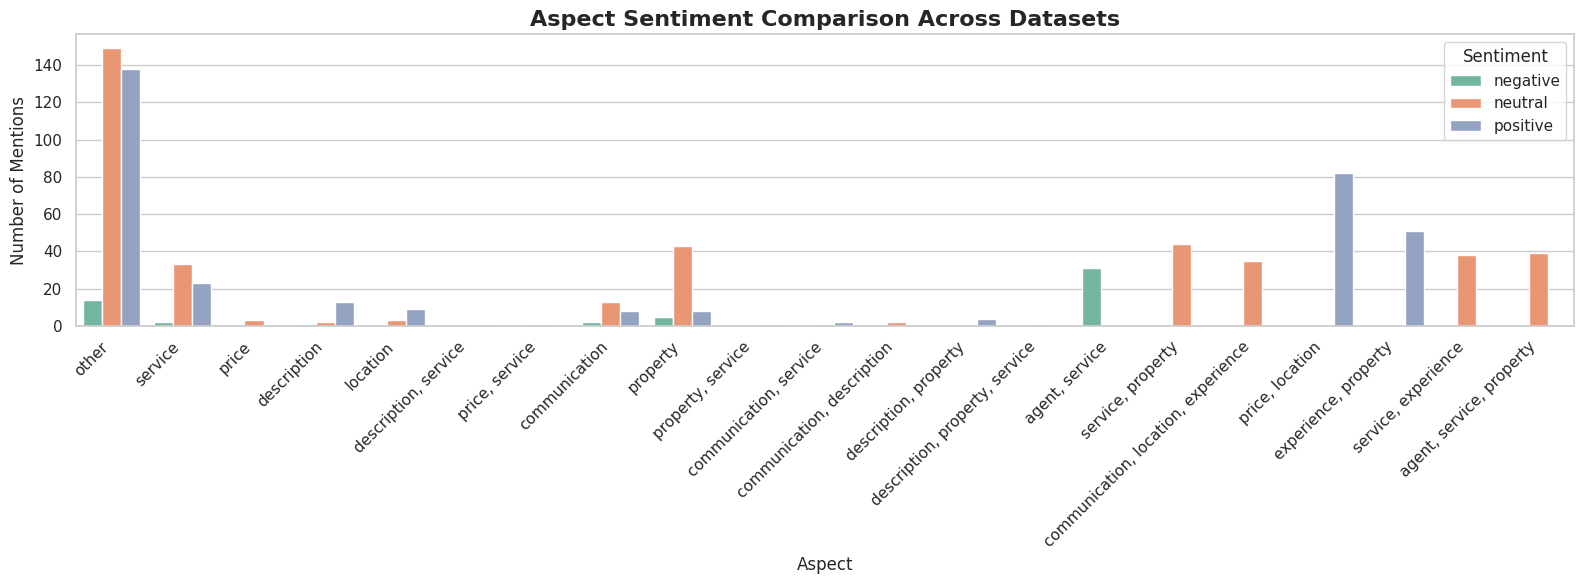

In [108]:
# STEP 1: Prepare secondary dataset aspect + sentiment
secondary_aspect_sentiment = secondary_df[['aspect', 'sentiment']].copy()
secondary_aspect_sentiment['source'] = 'Secondary'

# STEP 2: Prepare primary dataset (combine like & improve)
like_aspect_sentiment = primary_df_cleaned[['like_aspect', 'like_sentiment']].rename(
    columns={'like_aspect': 'aspect', 'like_sentiment': 'sentiment'})
like_aspect_sentiment['source'] = 'Primary (like)'

improve_aspect_sentiment = primary_df_cleaned[['improve_aspect', 'improve_sentiment']].rename(
    columns={'improve_aspect': 'aspect', 'improve_sentiment': 'sentiment'})
improve_aspect_sentiment['source'] = 'Primary (improve)'

# STEP 3: Combine all
combined_aspect_sentiment = pd.concat([
    like_aspect_sentiment,
    improve_aspect_sentiment,
    secondary_aspect_sentiment
], ignore_index=True)

# STEP 4: Plot Comparison
plt.figure(figsize=(16, 6))
sns.countplot(
    data=combined_aspect_sentiment,
    x='aspect',
    hue='sentiment',
    palette='Set2',
    hue_order=['negative', 'neutral', 'positive']
)
plt.title("Aspect Sentiment Comparison Across Datasets", fontsize=16, weight='bold')
plt.xlabel("Aspect")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


In [60]:
# Define keywords for aspect extraction
aspect_keywords = {
    'price': ['price', 'cost', 'expensive', 'cheap'],
    'location': ['location', 'area', 'neighborhood'],
    'communication': ['communication', 'response', 'reply', 'contact'],
    'description': ['description', 'pictures', 'photos', 'details'],
    'property': ['property', 'house', 'flat', 'apartment'],
    'service': ['service', 'support', 'agent', 'platform']
}

# Define aspect extraction function
def extract_aspect(text, keywords_dict):
    found = []
    for aspect, words in keywords_dict.items():
        for word in words:
            if word in text.lower():
                found.append(aspect)
                break
    return ', '.join(found) if found else 'other'

# Apply to primary dataset
primary_df_cleaned['like_aspect'] = primary_df_cleaned['like_clean'].apply(lambda x: extract_aspect(x, aspect_keywords))
primary_df_cleaned['improve_aspect'] = primary_df_cleaned['improve_clean'].apply(lambda x: extract_aspect(x, aspect_keywords))


<ipython-input-60-e974ba1481ae>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['like_aspect'] = primary_df_cleaned['like_clean'].apply(lambda x: extract_aspect(x, aspect_keywords))
<ipython-input-60-e974ba1481ae>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['improve_aspect'] = primary_df_cleaned['improve_clean'].apply(lambda x: extract_aspect(x, aspect_keywords))


In [61]:
primary_df_cleaned['like_sentiment'] = primary_df_cleaned['like_clean'].apply(get_sentiment)
primary_df_cleaned['improve_sentiment'] = primary_df_cleaned['improve_clean'].apply(get_sentiment)


<ipython-input-61-8fd6c2442c2f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['like_sentiment'] = primary_df_cleaned['like_clean'].apply(get_sentiment)
<ipython-input-61-8fd6c2442c2f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['improve_sentiment'] = primary_df_cleaned['improve_clean'].apply(get_sentiment)


In [62]:
secondary_df_cleaned['review_clean'] = secondary_df_cleaned['review'].str.lower().str.replace(r'[^\w\s]', '', regex=True)
secondary_df_cleaned['review_sentiment'] = secondary_df_cleaned['review_clean'].apply(get_sentiment)


In [63]:
print("Primary missing values:\n", primary_df_cleaned.isnull().sum())
print("\nSecondary missing values:\n", secondary_df_cleaned.isnull().sum())


Primary missing values:
 timestamp                                                                                                     0
total_score                                                                                                   0
what_is_your_age?                                                                                             0
what_is_your_age?__[score]                                                                                    0
what_is_your_age?__[feedback]                                                                               201
what_is_your_location_or_city?                                                                                2
what_is_your_location_or_city?__[score]                                                                       0
what_is_your_location_or_city?__[feedback]                                                                  201
what_was_your_most_recent_interaction_with_real_estate?                        

In [64]:
print(primary_df_cleaned.columns)


Index(['timestamp', 'total_score', 'what_is_your_age?',
       'what_is_your_age?__[score]', 'what_is_your_age?__[feedback]',
       'what_is_your_location_or_city?',
       'what_is_your_location_or_city?__[score]',
       'what_is_your_location_or_city?__[feedback]',
       'what_was_your_most_recent_interaction_with_real_estate?',
       'what_was_your_most_recent_interaction_with_real_estate?__[score]',
       'what_was_your_most_recent_interaction_with_real_estate?__[feedback]',
       'which_platform_or_service_did_you_use?__(e.g.,_airbnb,_trustpilot,_zameen,_olx,_local_agent)',
       'which_platform_or_service_did_you_use?__(e.g.,_airbnb,_trustpilot,_zameen,_olx,_local_agent)__[score]',
       'which_platform_or_service_did_you_use?__(e.g.,_airbnb,_trustpilot,_zameen,_olx,_local_agent)__[feedback]',
       'how_would_you_rate_your_overall_experience?',
       'how_would_you_rate_your_overall_experience?__[score]',
       'how_would_you_rate_your_overall_experience?__[feedback]'

In [65]:
# Create token columns by splitting cleaned text
primary_df_cleaned['like_tokens'] = primary_df_cleaned['like_clean'].apply(lambda x: x.split())
primary_df_cleaned['improve_tokens'] = primary_df_cleaned['improve_clean'].apply(lambda x: x.split())


<ipython-input-65-dfe31d63fe9b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['like_tokens'] = primary_df_cleaned['like_clean'].apply(lambda x: x.split())
<ipython-input-65-dfe31d63fe9b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['improve_tokens'] = primary_df_cleaned['improve_clean'].apply(lambda x: x.split())


In [66]:
top_positive_like = get_top_words(primary_df_cleaned, 'like_tokens', 'like_sentiment', 'positive')
top_negative_like = get_top_words(primary_df_cleaned, 'like_tokens', 'like_sentiment', 'negative')


In [67]:
def get_top_words(df, token_col, sentiment_col, sentiment_label, top_n=10):
    words = []
    for tokens in df[df[sentiment_col] == sentiment_label][token_col]:
        words.extend([word for word in tokens if word not in stop_words])
    return Counter(words).most_common(top_n)

# Example: top words in positive "like" responses
top_positive_like = get_top_words(primary_df_cleaned, 'like_tokens', 'like_sentiment', 'positive')
top_negative_like = get_top_words(primary_df_cleaned, 'like_tokens', 'like_sentiment', 'negative')


In [116]:
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
        text = re.sub(r'\d+', '', text)      # remove numbers
        return text.strip()
    return ""

# Apply to original text fields
df['like_clean'] = df['what_did_you_like_most_about_your_experience?'].apply(clean_text)
df['improve_clean'] = df['what_could_have_been_improved_in_your_opinion?'].apply(clean_text)


KeyError: 'what_did_you_like_most_about_your_experience?'

In [69]:
# Step 1: Define top words for 'improve' feedback
top_positive_improve = get_top_words(primary_df_cleaned, 'improve_clean', 'improve_sentiment', 'positive')
top_negative_improve = get_top_words(primary_df_cleaned, 'improve_clean', 'improve_sentiment', 'negative')


In [115]:
# Step 1:
secondary_df_cleaned['review_tokens'] = secondary_df_cleaned['review_clean'].apply(lambda x: x.split())

# Step 2: Now run your word frequency code
top_positive_review = get_top_words(secondary_df_cleaned, 'review_tokens', 'review_sentiment', 'positive')
top_negative_review = get_top_words(secondary_df_cleaned, 'review_tokens', 'review_sentiment', 'negative')

# Step 3: Plot results
plot_top_words(top_positive_review, "Top Words in Positive Reviews (Secondary)")
plot_top_words(top_negative_review, "Top Words in Negative Reviews (Secondary)")


NameError: name 'plot_top_words' is not defined

In [71]:
secondary_df['review_clean'] = secondary_df['Review'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# Re-create sentiment if missing
secondary_df['review_sentiment'] = secondary_df['review_clean'].apply(
    lambda x: 'positive' if 'good' in x or 'great' in x or 'happy' in x else (
        'negative' if 'bad' in x or 'terrible' in x or 'worst' in x else 'neutral')
)


In [72]:
aspect_keywords = {
    'agent': ['agent', 'staff', 'person'],
    'communication': ['communication', 'response', 'reply', 'contact'],
    'price': ['price', 'cost', 'expensive', 'cheap'],
    'location': ['location', 'area', 'neighborhood'],
    'documents': ['document', 'paper', 'verification'],
    'service': ['service', 'support', 'help'],
    'experience': ['experience', 'process', 'smooth', 'easy'],
    'property': ['property', 'house', 'flat', 'apartment', 'room']
}

def extract_aspects(text, aspect_dict):
    found = []
    for aspect, keywords in aspect_dict.items():
        if any(kw in text for kw in keywords):
            found.append(aspect)
    return found

# Apply aspect extraction
secondary_df['aspects'] = secondary_df['review_clean'].apply(lambda x: extract_aspects(x, aspect_keywords))


In [73]:
# From primary open-ended questions (assumed you already cleaned and tokenized)
# Let's use like_clean + improve_clean for aspect tagging

# Reuse aspect_keywords defined earlier
def extract_aspects(text, aspect_dict):
    found = []
    for aspect, keywords in aspect_dict.items():
        if any(kw in text for kw in keywords):
            found.append(aspect)
    return found

# Apply to primary dataset
primary_df_cleaned['like_aspects'] = primary_df_cleaned['like_clean'].apply(lambda x: extract_aspects(x, aspect_keywords))
primary_df_cleaned['improve_aspects'] = primary_df_cleaned['improve_clean'].apply(lambda x: extract_aspects(x, aspect_keywords))

# Explode both parts
like_aspects = primary_df_cleaned[['like_clean', 'like_aspects', 'like_sentiment']].explode('like_aspects').dropna()
like_aspects = like_aspects.rename(columns={'like_aspects': 'aspect', 'like_sentiment': 'sentiment'})
like_aspects['source'] = 'Primary (Like)'

improve_aspects = primary_df_cleaned[['improve_clean', 'improve_aspects', 'improve_sentiment']].explode('improve_aspects').dropna()
improve_aspects = improve_aspects.rename(columns={'improve_aspects': 'aspect', 'improve_sentiment': 'sentiment'})
improve_aspects['source'] = 'Primary (Improve)'


<ipython-input-73-0da1eb5311b3>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['like_aspects'] = primary_df_cleaned['like_clean'].apply(lambda x: extract_aspects(x, aspect_keywords))
<ipython-input-73-0da1eb5311b3>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary_df_cleaned['improve_aspects'] = primary_df_cleaned['improve_clean'].apply(lambda x: extract_aspects(x, aspect_keywords))


## 5. 📈 Statistical Tests

## 6. 💬 Sentiment Analysis (General)

ValueError: Could not interpret value `like_sentiment` for `x`. An entry with this name does not appear in `data`.

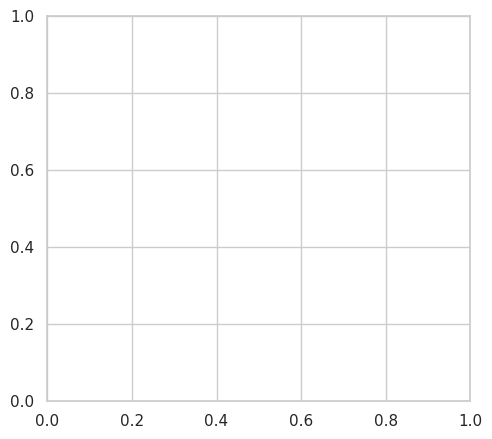

In [120]:
# Set visual style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))

# Plot for "What did you like most?" sentiment
plt.subplot(1, 2, 1)
sns.countplot(x='like_sentiment', data=primary_df, palette='viridis')
plt.title('Sentiment Distribution (What did you like most?)')
plt.xlabel('Sentiment')
plt.ylabel('Count')

# Plot for "What could be improved?" sentiment
plt.subplot(1, 2, 2)
sns.countplot(x='improve_sentiment', data=primary_df, palette='magma')
plt.title('Sentiment Distribution (What could be improved?)')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [96]:
# Rename review_sentiment to sentiment in secondary_df
secondary_df = secondary_df.rename(columns={'review_sentiment': 'sentiment'})


## 7. 🧠 Aspect-Based Sentiment Analysis (ABSA)

In [118]:
# Set theme for professional appearance
sns.set_theme(style="whitegrid")

# Reorder sentiments manually to maintain consistent stacking
aspect_sentiment_df['sentiment'] = pd.Categorical(
    aspect_sentiment_df['sentiment'], categories=['negative', 'neutral', 'positive'], ordered=True
)

# Count sentiment per aspect
aspect_sentiment_counts = aspect_sentiment_df.groupby(['aspect', 'sentiment']).size().reset_index(name='count')

# Plot with seaborn
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=aspect_sentiment_counts,
    x='aspect',
    y='count',
    hue='sentiment',
    palette={'positive': '#2ecc71', 'neutral': '#f1c40f', 'negative': '#e74c3c'}
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

# Chart settings
plt.title('Sentiment per Aspect in Primary Dataset', fontsize=16, weight='bold')
plt.xlabel('Aspect', fontsize=12)
plt.ylabel('Number of Mentions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


NameError: name 'aspect_sentiment_df' is not defined

In [98]:
# STEP 1: Prepare secondary dataset aspect + sentiment
secondary_aspect_sentiment = secondary_df[['aspect', 'sentiment']].copy()
secondary_aspect_sentiment['source'] = 'Secondary'


In [99]:
secondary_aspect = aspect_df.copy()
secondary_aspect['source'] = 'Secondary'
secondary_aspect = secondary_aspect[['aspect', 'sentiment', 'source']]


In [100]:
# Combine all into one DataFrame
combined_aspects = pd.concat([
    like_aspects[['aspect', 'sentiment', 'source']],
    improve_aspects[['aspect', 'sentiment', 'source']],
    secondary_aspect
])


<ipython-input-101-1bd64ea7f64a>:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=pivot_df, x='aspect', y='count', hue='sentiment', ci=None, palette='RdYlGn', hue_order=['negative', 'neutral', 'positive'])


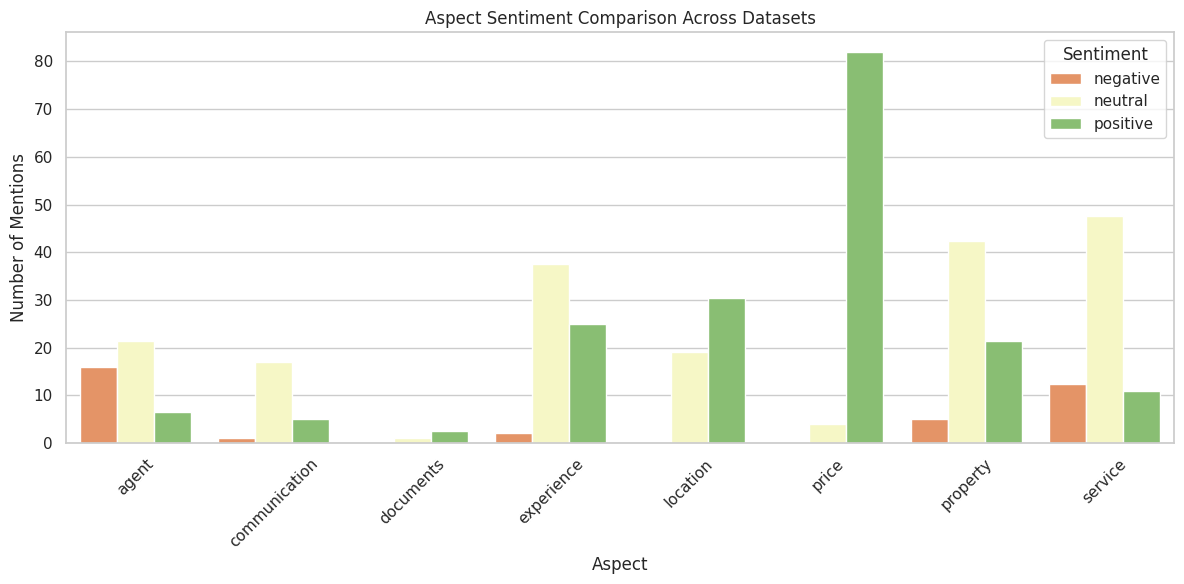

In [101]:
# Count sentiment by aspect and source
pivot_df = combined_aspects.groupby(['aspect', 'source', 'sentiment']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=pivot_df, x='aspect', y='count', hue='sentiment', ci=None, palette='RdYlGn', hue_order=['negative', 'neutral', 'positive'])
plt.title('Aspect Sentiment Comparison Across Datasets')
plt.xlabel('Aspect')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


## 8. 🔤 Top Word Frequency Analysis

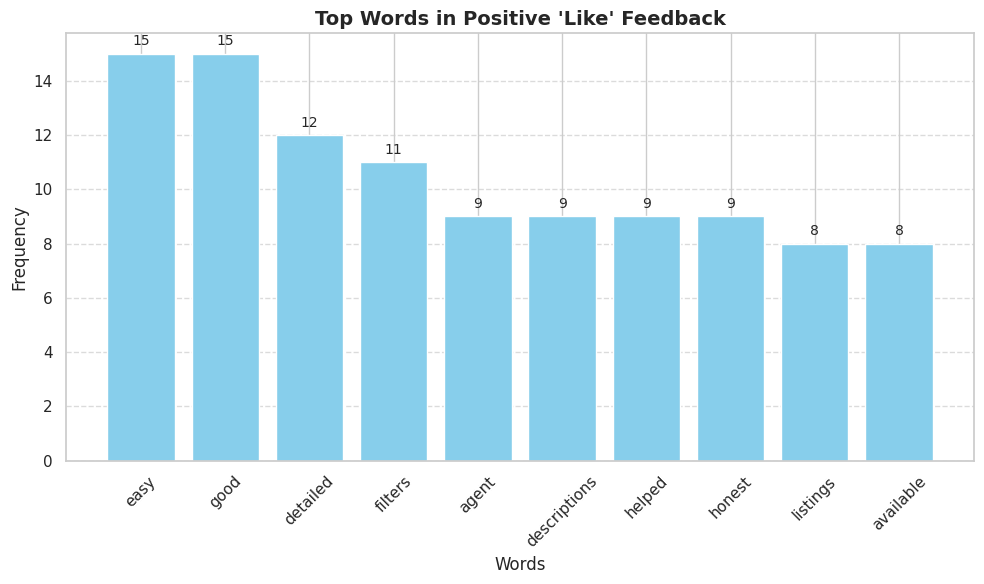

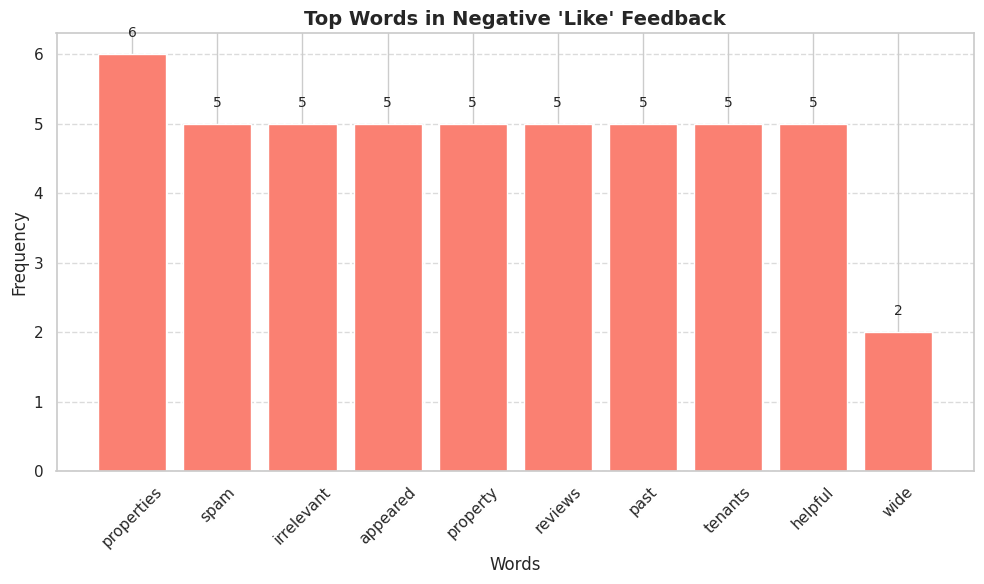

In [102]:
def plot_top_words_pretty(freq_dict, title, color):
    words = list(freq_dict.keys())
    counts = list(freq_dict.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(words, counts, color=color)
    plt.title(title, fontsize=14, weight='bold')
    plt.xlabel('Words', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.2, int(yval),
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

# Plot
plot_top_words_pretty(top_positive_like_counter, "Top Words in Positive 'Like' Feedback", 'skyblue')
plot_top_words_pretty(top_negative_like_counter, "Top Words in Negative 'Like' Feedback", 'salmon')


In [103]:
def plot_top_words_pretty(word_counts, title, color):
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(word_counts.keys(), word_counts.values(), color=color)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel('Words', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

    # Add value labels on top
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


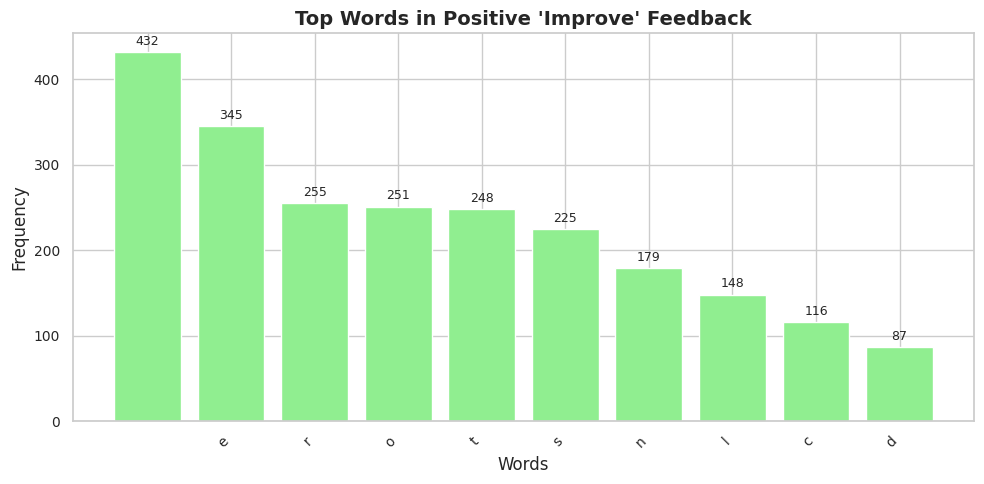

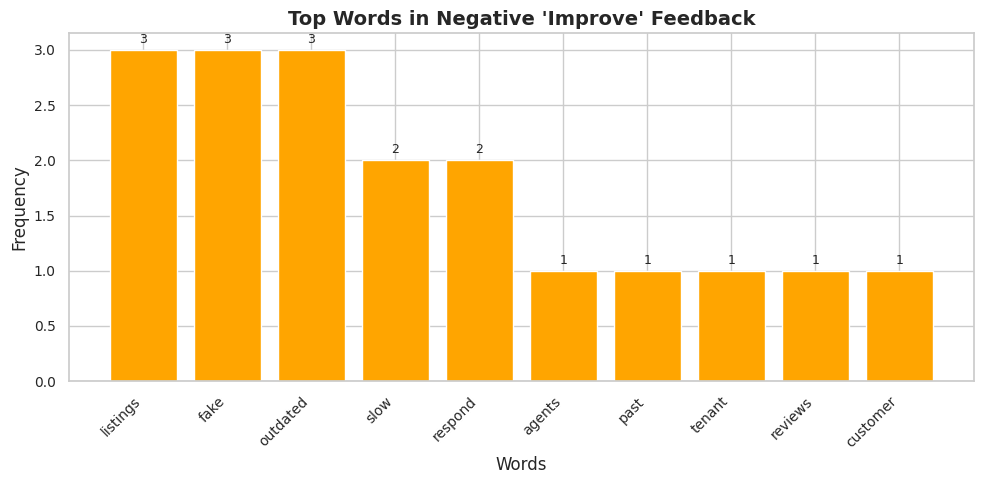

In [104]:
# Step 2: Create Counters
#top_positive_improve_counter = Counter(list(top_positive_improve))
#top_negative_improve_counter = Counter(list(top_negative_improve))

top_positive_improve_counter = dict(top_positive_improve)
top_negative_improve_counter = dict(top_negative_improve)


# Step 3: Plot
plot_top_words_pretty(top_positive_improve_counter, "Top Words in Positive 'Improve' Feedback", 'lightgreen')
plot_top_words_pretty(top_negative_improve_counter, "Top Words in Negative 'Improve' Feedback", 'orange')


## 9. 🧾 Summary Table or Export Helpers

## 10. 📌 Extra / Scratch / Optional Code

In [105]:
# Summary statistics
primary_df.describe(include='number')

# Mode for categorical fields
for col in primary_df.select_dtypes(include='object').columns:
    print(f"{col}: {primary_df[col].mode(dropna=True).iloc[0]}")


Timestamp: 2025/05/13 1:47:29 AM GMT+3
Total score: 0.00 / 0
What is your age? : 25–34
What is your age?  [Score]: -- / 0
What is your location or city? : Lahore
What is your location or city?  [Score]: -- / 0
What was your most recent interaction with real estate? : Renting
What was your most recent interaction with real estate?  [Score]: -- / 0
Which platform or service did you use?  (e.g., Airbnb, Trustpilot, Zameen, OLX, Local agent) : OLX
Which platform or service did you use?  (e.g., Airbnb, Trustpilot, Zameen, OLX, Local agent)  [Score]: -- / 0
How would you rate your overall experience?  [Score]: -- / 0
The property description matched the actual property.  [Score]: -- / 0
How satisfied were you with the agent’s or platform’s communication?  [Score]: -- / 0
Would you recommend this platform or agent to others?  [Score]: -- / 0
What did you like most about your experience? : Filters for budget and size worked very well.

What did you like most about your experience?  [Score]: --

<ipython-input-106-422b39b47110>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-106-422b39b47110>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-106-422b39b47110>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
<ipython-input-106-422b39b47110>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


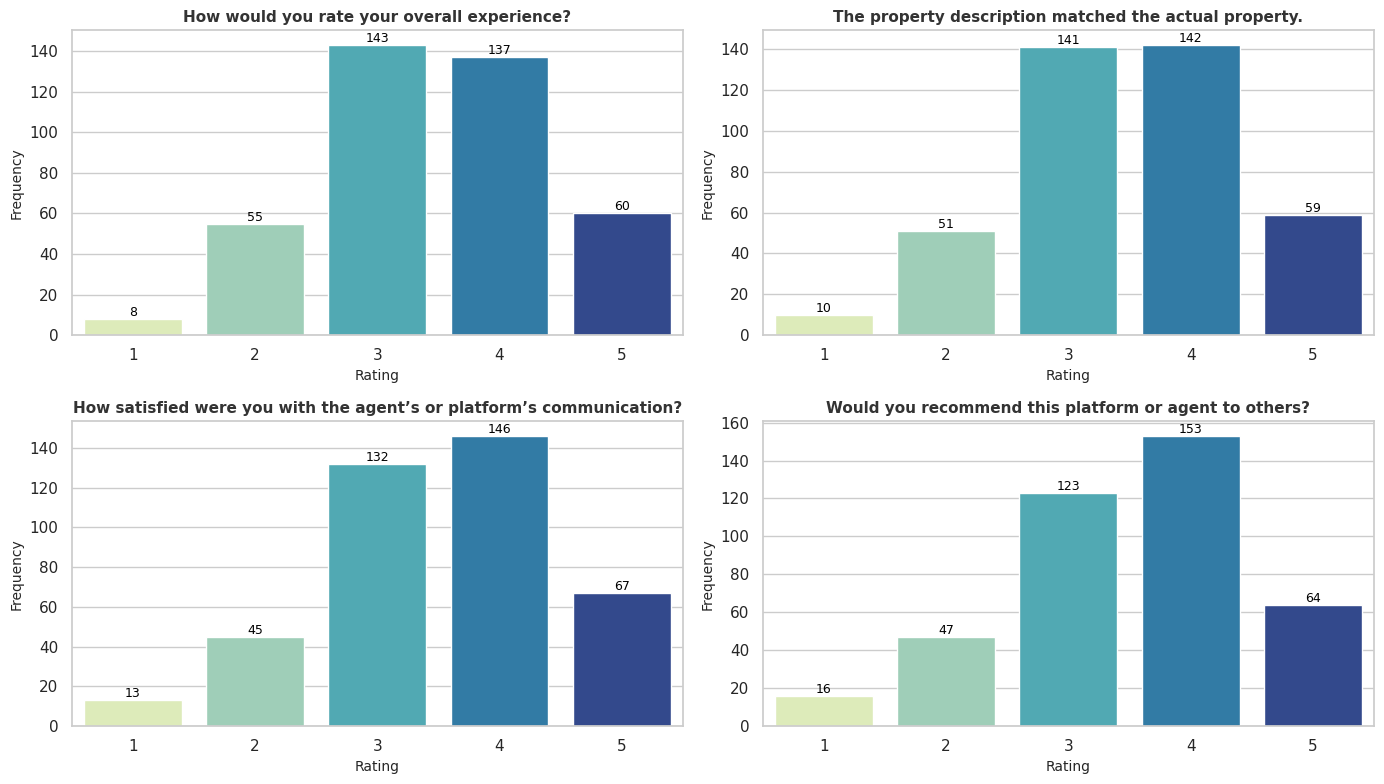

In [106]:
# Survey columns
cols = [
    'How would you rate your overall experience? ',
    'The property description matched the actual property. ',
    'How satisfied were you with the agent’s or platform’s communication? ',
    'Would you recommend this platform or agent to others? '
]

# Set visual theme
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("YlGnBu", 5)

# Create subplot grid
plt.figure(figsize=(14, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    ax = sns.countplot(
        data=primary_df,
        x=col,
        palette=custom_palette,
        order=sorted(primary_df[col].dropna().unique())
    )

    plt.title(col.strip(), fontsize=11, fontweight='bold', color='#333333')
    plt.xlabel("Rating", fontsize=10)
    plt.ylabel("Frequency", fontsize=10)

    # Count label on bars
    for p in ax.patches:
        count = int(p.get_height())
        ax.annotate(f'{count}', (p.get_x() + p.get_width() / 2., count),
                    ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()